# 🧩 Task 1 (Easy): Build & Query the GIKI Knowledge Graph
### AI 311 – Knowledge Representation & Problem Solving

A **knowledge graph** stores facts as **triples**: `(subject, relation, object)`.
> *"Ms. Aneeqa —teaches→ AI311"*  is one fact. Chain thousands of these together and you get the kind of graph that powers Google Search, Alexa, and medical AI.

**Your mission this session:** turn a pile of facts about GIKI into a graph you can *see* and *ask questions to*.

Run each cell with **Shift + Enter**. 🚀

> ### 📌 How to use this notebook
> Some cells contain blanks written as `______`. **Those are for you to fill in** — replace each `______` with the correct code, then run the cell.
>
> If you run a cell that still has a `______` in it, you'll see `NameError: name '______' is not defined`. **That's expected** — it just means there's still a blank to complete. Fill it in and re-run. ✅
>
> Every blank has a `# TODO` comment and a hint right next to it, and the expected answer is shown in the comment (e.g. `# expected: ['Ms. Aneeqa']`).

## Step 0 — Setup
`networkx` and `matplotlib` are pre-installed on Colab, so this just imports them.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
print('networkx', nx.__version__, '– ready!')

networkx 3.6.1 – ready!


## Step 1 — The facts of the GIKI world
Every fact is a `(subject, relation, object)` triple.

In [ ]:
# The GIKI world, written as (subject, relation, object) triples.
# This is EXACTLY how real knowledge graphs (Wikidata, Google's KG) store facts.
triples = [
    # --- who teaches what ---
    ("Ms. Aneeqa", "teaches", "AI311"),
    ("Dr. Ahmed",  "teaches", "AI201"),
    ("Dr. Ahmed",  "teaches", "CS101"),
    ("Dr. Sana",   "teaches", "AI305"),
    ("Dr. Sana",   "teaches", "MATH101"),
    ("Dr. Bilal",  "teaches", "CS210"),

    # --- prerequisites:  (A is a prerequisite_of B) ---
    ("CS101",   "prerequisite_of", "CS210"),
    ("CS210",   "prerequisite_of", "AI201"),
    ("AI201",   "prerequisite_of", "AI305"),
    ("AI305",   "prerequisite_of", "AI311"),
    ("MATH101", "prerequisite_of", "AI305"),

    # --- who is enrolled in what ---
    ("Zain",   "enrolled_in", "AI311"),
    ("Zain",   "enrolled_in", "AI305"),
    ("Hira",   "enrolled_in", "AI311"),
    ("Hira",   "enrolled_in", "AI305"),
    ("Hira",   "enrolled_in", "MATH101"),
    ("Usman",  "enrolled_in", "AI201"),
    ("Usman",  "enrolled_in", "CS210"),
    ("Ayesha", "enrolled_in", "AI311"),
    ("Ayesha", "enrolled_in", "AI201"),
    ("Fatima", "enrolled_in", "AI305"),
    ("Fatima", "enrolled_in", "MATH101"),
    ("Hamza",  "enrolled_in", "CS210"),
    ("Hamza",  "enrolled_in", "CS101"),

    # --- friendships ---
    ("Zain", "friends_with", "Hira"),
    ("Hira", "friends_with", "Ayesha"),
    ("Usman","friends_with", "Hamza"),
    ("Zain", "friends_with", "Fatima"),

    # --- which department offers the course ---
    ("AI311",  "offered_by", "FCSE"),
    ("AI201",  "offered_by", "FCSE"),
    ("AI305",  "offered_by", "FCSE"),
    ("CS101",  "offered_by", "FCSE"),
    ("CS210",  "offered_by", "FCSE"),
    ("MATH101","offered_by", "FCSE"),
]
print(f"We have {len(triples)} facts about the GIKI world.")
triples[:5]

We have 34 facts about the GIKI world.


[('Ms. Aneeqa', 'teaches', 'AI311'),
 ('Dr. Ahmed', 'teaches', 'AI201'),
 ('Dr. Ahmed', 'teaches', 'CS101'),
 ('Dr. Sana', 'teaches', 'AI305'),
 ('Dr. Sana', 'teaches', 'MATH101')]

## Step 2 — Turn the facts into a graph
Each triple becomes a **labelled arrow** from the subject to the object.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# A MultiDiGraph = a DIRECTED graph that allows several labelled edges
# between the same two nodes. Perfect for a knowledge graph.
G = nx.MultiDiGraph()
for subject, relation, obj in triples:
    G.add_edge(subject, obj, relation=relation)

print("Nodes (entities):", G.number_of_nodes())
print("Edges (facts):   ", G.number_of_edges())

Nodes (entities): 17
Edges (facts):    34


## Step 3 — See your graph 👀
Run this and admire it. Try changing `seed=42` to any number and re-run to get a nicer layout.

/tmp/ipykernel_3365/3412484581.py:25: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.axis("off"); plt.tight_layout(); plt.show()
/tmp/ipykernel_3365/3412484581.py:25: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.axis("off"); plt.tight_layout(); plt.show()
/tmp/ipykernel_3365/3412484581.py:25: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.axis("off"); plt.tight_layout(); plt.show()
/tmp/ipykernel_3365/3412484581.py:25: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.axis("off"); plt.tight_layout(); plt.show()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN

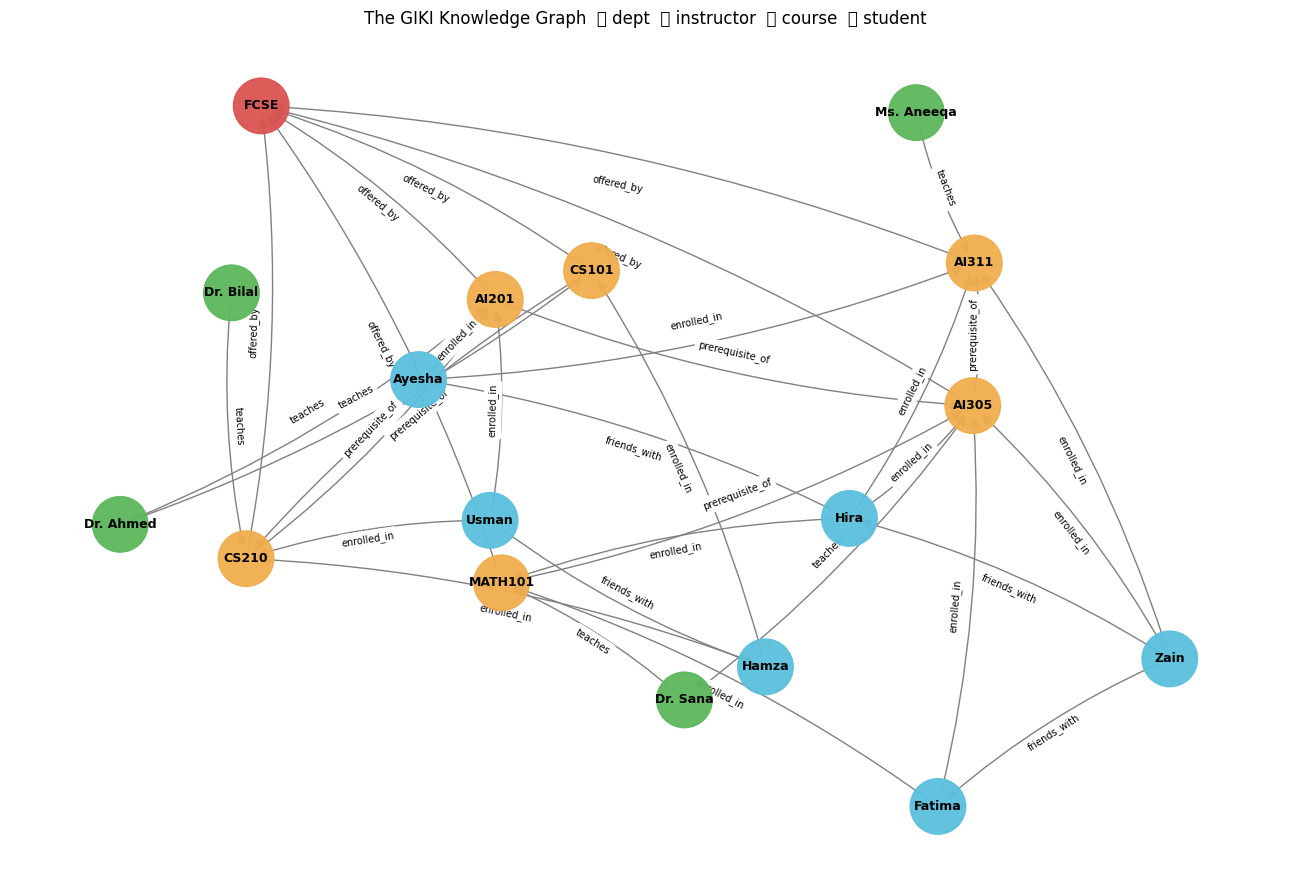

In [ ]:
# Colour each node by what KIND of thing it is, so the graph is readable.
instructors = {s for s,r,o in triples if r == "teaches"}
students    = {s for s,r,o in triples if r == "enrolled_in"}
departments = {o for s,r,o in triples if r == "offered_by"}
courses     = {o for s,r,o in triples if r in ("teaches","enrolled_in","offered_by")} \
              | {s for s,r,o in triples if r in ("prerequisite_of","offered_by")}

def node_color(n):
    if n in departments: return "#d9534f"   # red   = department
    if n in instructors: return "#5cb85c"   # green = instructor
    if n in courses:     return "#f0ad4e"   # amber = course
    if n in students:    return "#5bc0de"   # blue  = student
    return "#cccccc"

plt.figure(figsize=(13, 9))
pos = nx.spring_layout(G, k=0.9, seed=42)          # try changing the seed!
colors = [node_color(n) for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=1600, alpha=0.95)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=15,
                       edge_color="gray", connectionstyle="arc3,rad=0.08")
edge_labels = {(u, v): d["relation"] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title("The GIKI Knowledge Graph  \U0001F534 dept  \U0001F7E2 instructor  \U0001F7E0 course  \U0001F535 student")
plt.axis("off"); plt.tight_layout(); plt.show()

## Step 4 — Ask the graph questions ✋ *(your turn!)*
A knowledge graph is only useful if you can **query** it. Fill in the `# TODO` lines.

**Hint:** for a node `x`,
- `G.out_edges(x, data=True)` gives arrows *leaving* x, each as `(x, target, {'relation': ...})`
- `G.in_edges(x, data=True)` gives arrows *entering* x.

In [ ]:
def who_teaches(course):
    """Return the instructor(s) of a course.
    TODO: keep incoming edges whose relation == 'teaches', return the source node."""
    return [u for u, v, d in G.in_edges(course, data=True) if d["relation"] == ______ ]  # TODO

print("Who teaches AI311? ->", who_teaches("AI311"))   # expected: ['Ms. Aneeqa']

NameError: name '______' is not defined

In [ ]:
def courses_of(student):
    """Return every course a student is enrolled in.
    TODO: use G.out_edges(...) and keep relation == 'enrolled_in'."""
    return [ ______ for u, v, d in G.out_edges(student, data=True) if ______ ]  # TODO

print("Hira is taking ->", courses_of("Hira"))         # expected: AI311, AI305, MATH101

In [ ]:
# TODO: build a graph of ONLY the prerequisite_of edges, then find the chain.
prereq_edges = [(u, v) for u, v, d in G.edges(data=True) if d["relation"] == ______ ]  # TODO
PG = nx.DiGraph(prereq_edges)

print("Direct prereq(s) of AI311 ->", list(PG.predecessors("AI311")))
# TODO: use nx.shortest_path to print the full chain from CS101 to AI311
print("Full path CS101 -> AI311  ->", ______ )  # TODO

In [ ]:
# Which student is the most "connected" (highest degree)?
students = sorted({s for s, r, o in triples if r == "enrolled_in"})
degree = {s: ______ for s in students}     # TODO: use G.degree(s)
print("Connection counts:", degree)
print("Most connected student ->", max(degree, key=degree.get))

## 🏆 Mini-challenge: *Stump the Graph!*
In pairs, invent **one question** your graph can answer and write the code for it. Ideas:
- *"Which two students share the most courses?"*
- *"List every course offered by FCSE."*
- *"Who teaches a course that Zain is enrolled in?"* (a 2-hop question!)

The best question wins. Use the empty cell below.

In [ ]:
# Your 'stump the graph' question here:
